# 17.8 兩個4-bit值，如何裝進一個byte？


七個四位元數若各放一個int8，仍佔7byte。把兩碼放進同一byte，才只需4byte。最後一組只有一個值，另一半補格；拆回時要記得原本只有七項。

本工具的打包器容納有號整數−8至7，先加8映到碼0至15。第一碼放低四位，第二碼放高四位。例子−8、−1變碼0、7，byte是`0111 0000`，即`7×16+0=112`。


In [1]:
# @title 準備本節的工具（首次執行）
from pathlib import Path
import os
import subprocess
import sys

# Colab 會先下載專案；本機 Jupyter 沿用已開啟的 repo。
try:
    import google.colab
except ImportError:
    in_colab = False
else:
    in_colab = True

if in_colab:
    root = Path("/content/tiny-perceptron-vlm")
    if not root.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/birdhackor/tiny-perceptron-vlm.git", str(root)],
            env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"},
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-e", str(root)], check=True)
    os.chdir(root)

root = Path.cwd().resolve()
while not (root / "pyproject.toml").exists() and root != root.parent:
    root = root.parent
if not (root / "tiny_perceptron").is_dir():
    raise RuntimeError("本機請先依 course/first-steps.md 開啟 repo；免安裝練習可使用本節的 Colab 入口")
sys.path.insert(0, str(root))
import torch

torch.set_num_threads(1)
torch.manual_seed(42)

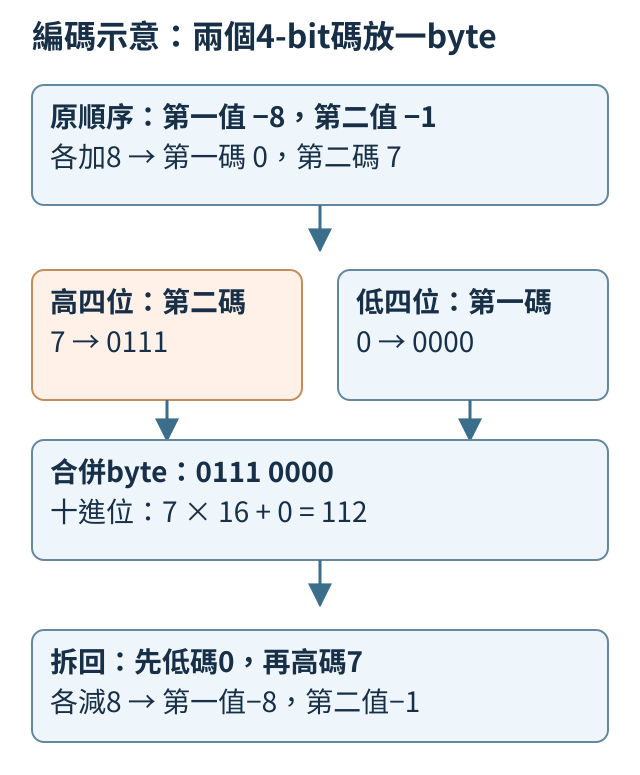

In [2]:
# @title 本節圖解
from IPython.display import SVG, display

display(SVG(filename=str(root / "course/figures/rewrite-17-int4-byte.svg")))

In [3]:
import torch
from tiny_perceptron.quantization import pack_int4, unpack_int4

q = torch.tensor([-8, -1, 0, 1, 7, 2, 3], dtype=torch.int8)
packed = pack_int4(q)
restored = unpack_int4(packed, q.shape)
print("原數字", q.tolist())
print("packed", packed.tolist(), "bytes", packed.numel() * packed.element_size())
print("拆回", restored.tolist())
assert torch.equal(q, restored)

原數字 [-8, -1, 0, 1, 7, 2, 3]
packed [112, 152, 175, 139] bytes 4
拆回 [-8, -1, 0, 1, 7, 2, 3]


`pack_int4`以左移四位安排高碼，再用位元OR合併；兩碼佔不同區域，所以不混在一起。拆回以`&15`取低碼、`>>4`取高碼，再減8。`q.shape`告訴工具原形狀與項數，裁去補格。

packed為`[112,152,175,139]`，佔4byte。末項3變碼11，另一半補碼8（代表0），所以最後byte是`8×16+11=139`。`assert torch.equal`確認整數拆回完全相同。

這個打包步驟是無損的，但之前浮點映到整數格時已可能有誤差。本章量化函數實際只使用對稱−7至7，留下−8碼不用；打包器可容納範圍與量化實際範圍也應分清。

完整層還需保存scale、形狀、bit設定和bias。普通乘法也不能把112當原權重使用，要按格式拆解或交給理解該格式的運算。

練習末尾增加4，八項仍佔4byte，最後高碼從補8變成12，byte改203。這讓原項數如何參與還原清楚可見。

<details>
<summary>補充：既有實驗、來源與完整測量範圍</summary>

正式4-bit模型的13個Linear共保存57,600 bytes整數碼、5,664 bytes逐列scale與2,560 bytes浮點bias，合計65,824 bytes的buffer。其他浮點參數還需102,912 bytes，兩邊相加才是[17.1](https://birdhackor.github.io/tiny-perceptron-vlm/17.1.html)的168,736 bytes。報告`storage.buffers`逐層列出這些數字，能核對刻度確實存下來了；它們是實際容器大小，不是先用參數個數除以二推估的理想值。

</details>
